In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import os
from PIL import Image
from sklearn.preprocessing import LabelEncoder
import snntorch.spikeplot as splt
from IPython.display import HTML

In [1]:
DATA_DIR = "../../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [9]:
train_df = pd.read_csv(f"{DATASET_DIR}/train1_multi.csv")

In [ ]:
from snntorch import spikegen

class CustomDatasetRate(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, num_steps=4, gain=1):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.num_steps = num_steps
        self.gain = gain

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            img = spikegen.rate(img, num_steps=self.num_steps, gain=self.gain)
            return img, label

class CustomDatasetLatency(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, num_steps=25, tau=1, threshold=0.01):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.num_steps = num_steps
        self.tau = tau
        self.threshold = threshold

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            img = spikegen.latency(img, num_steps=self.num_steps, tau=self.tau, threshold=self.threshold, normalize=True, linear=True, clip=True)
            return img, label
        
class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label


In [11]:
LE = LabelEncoder()
LE.fit(train_df["Label"])
train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

In [116]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
train_dataset_rate = CustomDatasetRate(train_df_encoded, f"{DATASET_DIR}/images", transform=transform, num_steps=100, gain=0.25)
train_dataset_latency = CustomDatasetLatency(train_df_encoded, f"{DATASET_DIR}/images", transform=transform, num_steps=4, tau=5, threshold=0.3)

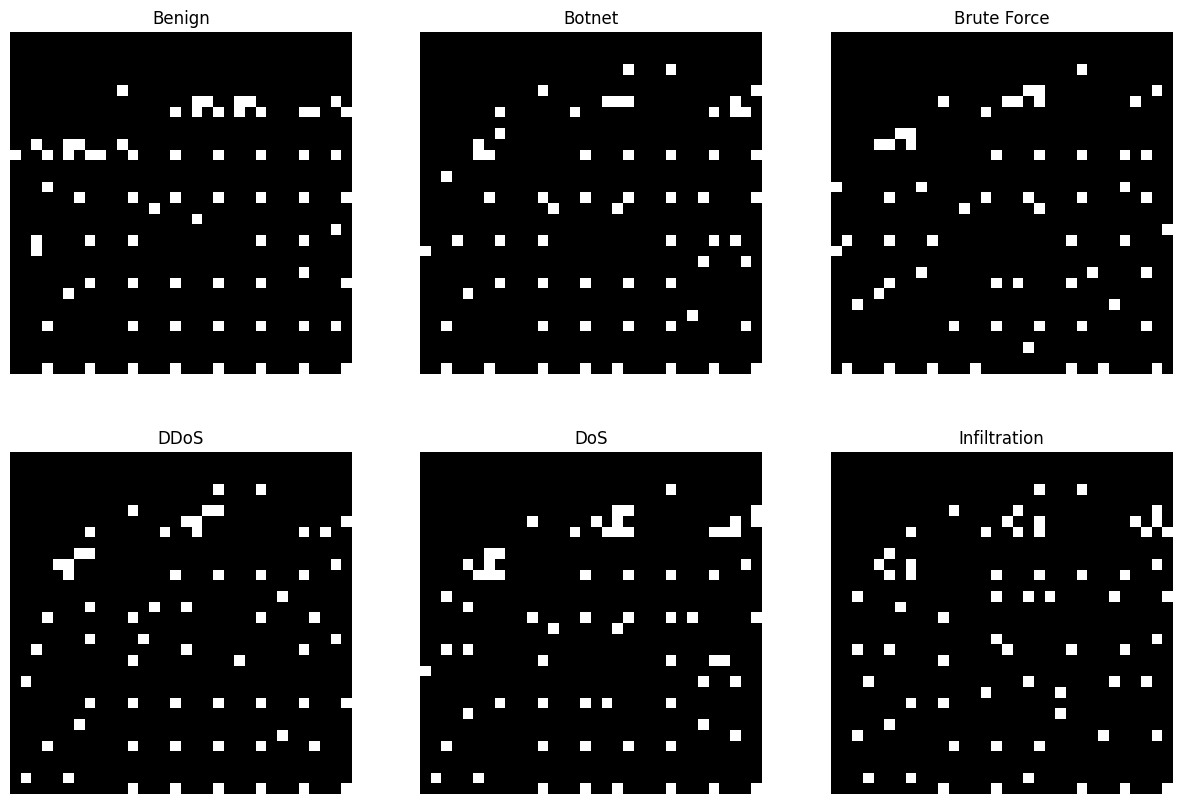

In [33]:
# plot image for each label from train_df_encoded (total labels - 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# plot from train_df_encoded
for label in range(6):
    img = train_df_encoded[train_df_encoded["Label"] == label].iloc[0]["Image"]
    img_path = os.path.join(f"{DATASET_DIR}/images", img)
    with Image.open(img_path) as img:
        axes[label//3, label%3].imshow(img, cmap="gray")
        axes[label//3, label%3].set_title(LE.inverse_transform([label])[0])
        axes[label//3, label%3].axis("off")
plt.show()


In [19]:
plt.rcParams['animation.ffmpeg_path'] = "C:\\Users\\para_\\AppData\\Local\\Microsoft\\WinGet\\Links\\ffmpeg.exe"

In [117]:
rate_spike_data_sample = train_dataset_rate[0][0][:,0]
latency_spike_data_sample = train_dataset_latency[0][0][:,0]

rate_spike_data_sample.shape, latency_spike_data_sample.shape

(torch.Size([100, 32, 32]), torch.Size([4, 32, 32]))

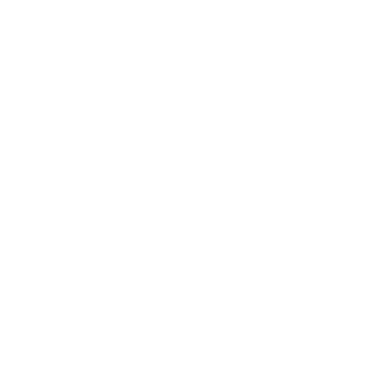

In [96]:
fig, ax = plt.subplots()
anim = splt.animator(rate_spike_data_sample, fig, ax)

HTML(anim.to_html5_video())

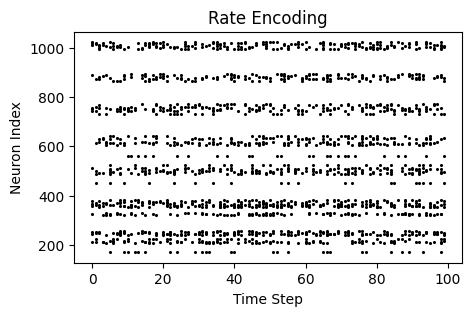

In [105]:
# reshape to a 2d tensor with num_step as first val
rate_spike_data_sample_reshaped = rate_spike_data_sample.reshape(100, -1)


fig = plt.figure(figsize=(5, 3), facecolor="w")
ax = fig.add_subplot(111)
splt.raster(rate_spike_data_sample_reshaped, ax, s=1.5, c="k")
plt.title("Rate Encoding")
plt.xlabel("Time Step")
plt.ylabel("Neuron Index")
plt.show()

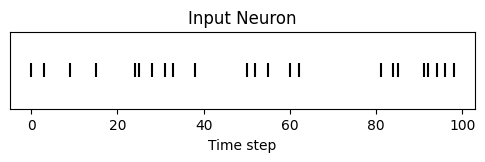

In [106]:
idx = 210  # index into 210th neuron

fig = plt.figure(facecolor="w", figsize=(6, 1))
ax = fig.add_subplot(111)

splt.raster(rate_spike_data_sample.reshape(100, -1)[:, idx].unsqueeze(1), ax, s=100, c="black", marker="|")

plt.title("Input Neuron")
plt.xlabel("Time step")
plt.yticks([])
plt.show()

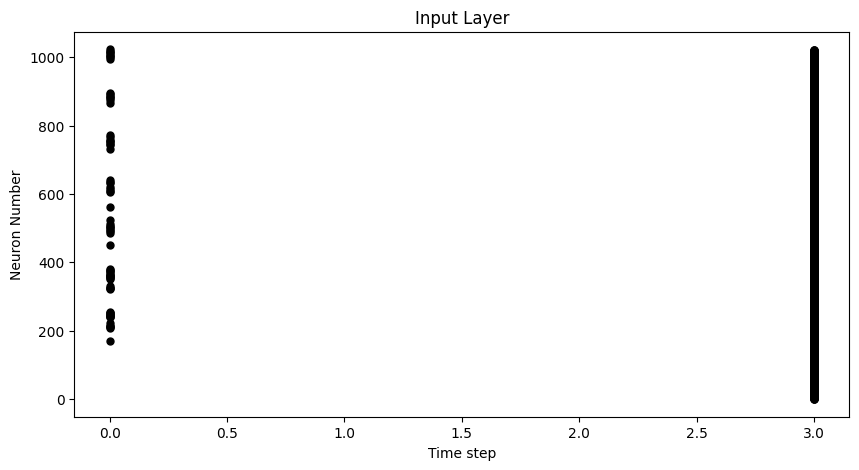

In [118]:
fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(latency_spike_data_sample.view(4, -1), ax, s=25, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

In [ ]:
fig, ax = plt.subplots()
anim = splt.animator(latency_spike_data_sample, fig, ax)

HTML(anim.to_html5_video())

In [5]:
base_dir = "../../models/checkpoints"

available_dirs = {
    0 : "cnn",
    1 : "multi_cnn",
    2 : "basic_snn",
    3 : "basic_multisnn",
    4 : "paper_snn",
    5 : "paper_multisnn"
}

In [11]:
def load_metrics_from_checkpoint(path, filename, only_history=True):
    full_path = os.path.join(path, filename)
    model_dict = torch.load(full_path, weights_only=False)

    return model_dict["history"] if only_history else model_dict

In [12]:
model_metrics = load_metrics_from_checkpoint(f"{base_dir}/{available_dirs[0]}", "abstract_cnn.pt", only_history=False)

model_metrics.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss', 'scheduler_state_dict', 'learning_rate', 'history'])

In [14]:
model_metrics["history"].keys()

dict_keys(['overall_accuracy', 'train_loss', 'val_loss', 'benign_metrics', 'malicious_metrics'])

In [ ]:
def plot_metrics(values_to_plot: dict, title, x_label, y_label):
    